# Heston Stochastic Volatility Model

Monte Carlo simulation of the Heston model. Comparing implied volatility smiles under different correlation parameters.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from heston import heston_european_call
from implied_vol import implied_vol
from black_scholes import black_scholes_call

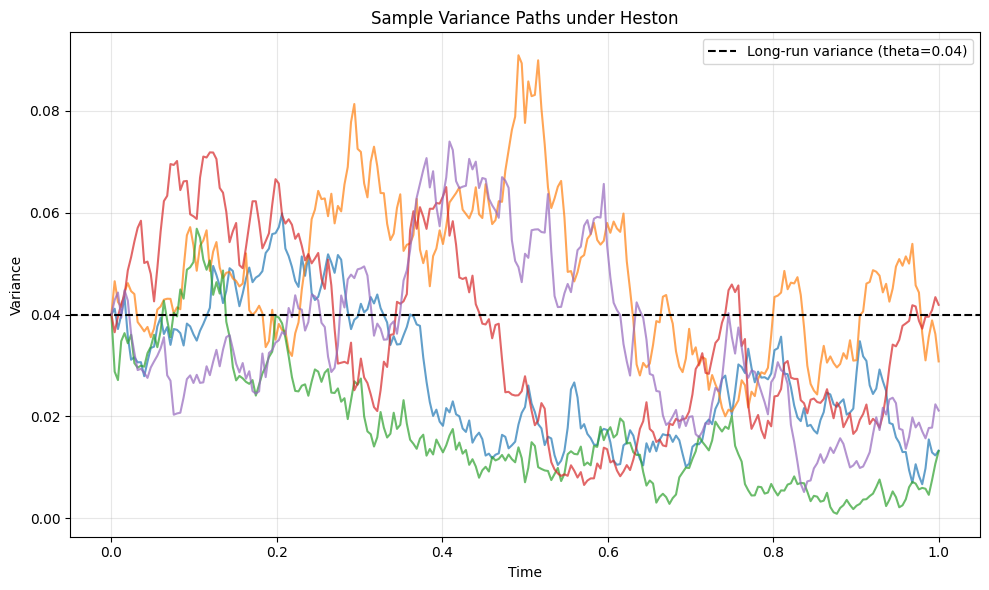

In [2]:
rng = np.random.default_rng(42)
S0, r, v0, kappa, theta, xi, rho, T = 100, 0.05, 0.04, 2.0, 0.04, 0.3, -0.7, 1.0
n_steps = 252
dt = T / n_steps

n_paths = 5
fig, ax = plt.subplots(figsize=(10, 6))

for _ in range(n_paths):
    v = v0
    path = [v]
    for _ in range(n_steps):
        Z = rng.standard_normal()
        v_pos = max(v, 0)
        v = v + kappa * (theta - v_pos) * dt + xi * np.sqrt(v_pos) * np.sqrt(dt) * Z
        path.append(max(v, 0))
    ax.plot(np.linspace(0, T, n_steps + 1), path, alpha=0.7)

ax.axhline(y=theta, color='black', linestyle='--', label=f'Long-run variance (theta={theta})')
ax.set_xlabel('Time')
ax.set_ylabel('Variance')
ax.set_title('Sample Variance Paths under Heston')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/heston_variance_paths.png', dpi=300)
plt.show()

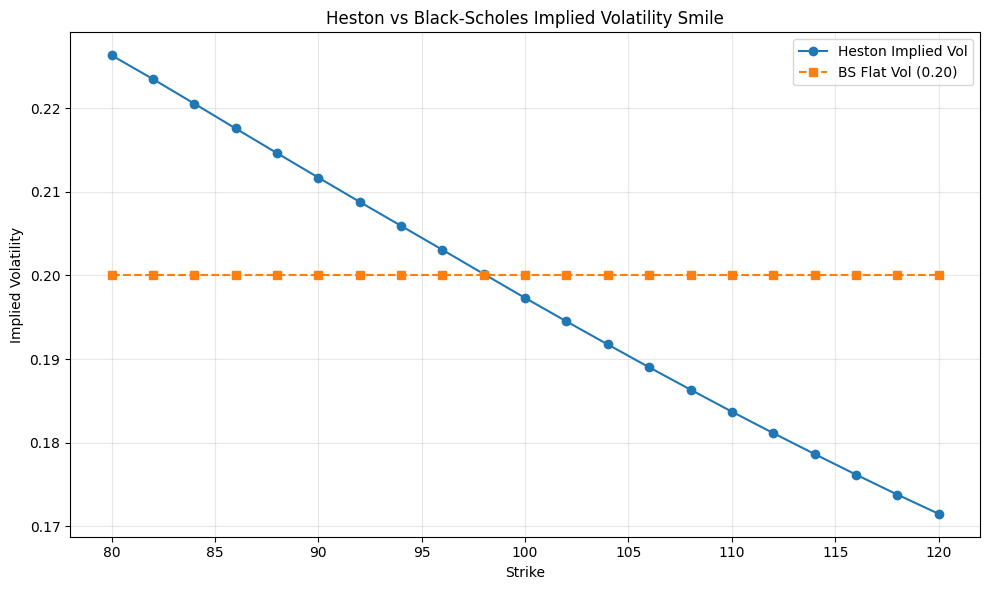

In [4]:
S0 = 100.0
r = 0.05
T = 1.0
v0 = 0.04
kappa = 2.0
theta = 0.04
xi = 0.3
rho = -0.7

strikes = np.arange(80, 121, 2)
heston_ivs = []
bs_ivs = []

for K in strikes:
    heston_price = heston_european_call(S0, float(K), r, v0, kappa, theta, xi, rho, T)['price']
    heston_iv = implied_vol(heston_price, S0, float(K), r, T)
    heston_ivs.append(heston_iv)

    bs_price = black_scholes_call(S0, float(K), r, 0.2, T)
    bs_iv = implied_vol(bs_price, S0, float(K), r, T)
    bs_ivs.append(bs_iv)

plt.figure(figsize=(10, 6))
plt.plot(strikes, heston_ivs, 'o-', label='Heston Implied Vol')
plt.plot(strikes, bs_ivs, 's--', label='BS Flat Vol (0.20)')
plt.xlabel('Strike')
plt.ylabel('Implied Volatility')
plt.title('Heston vs Black-Scholes Implied Volatility Smile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/heston_vs_bs_smile.png', dpi=300)
plt.show()

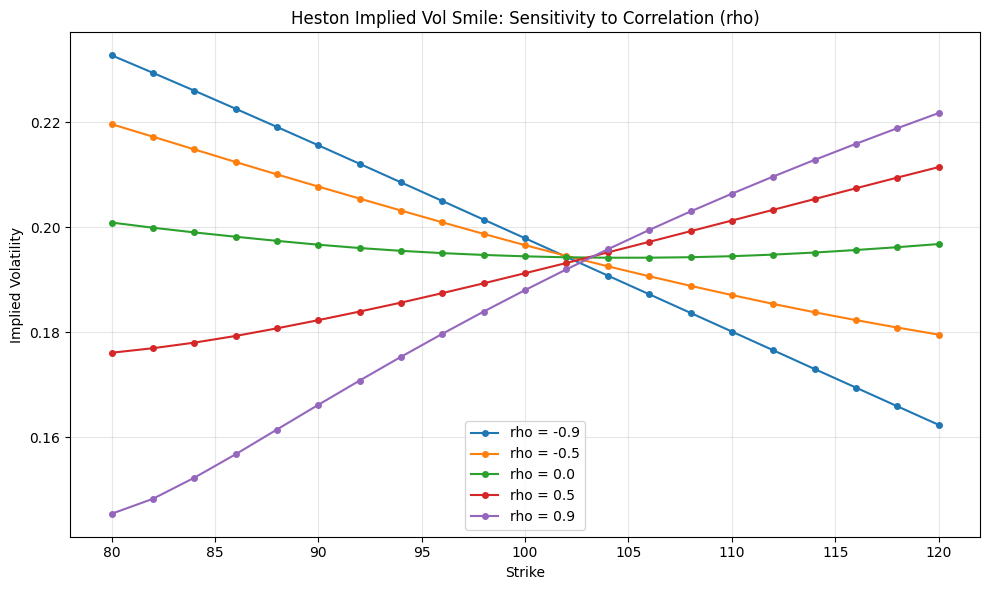

In [5]:
rhos = [-0.9, -0.5, 0.0, 0.5, 0.9]
strikes = np.arange(80, 121, 2)

plt.figure(figsize=(10, 6))

for rho_val in rhos:
    ivs = []
    for K in strikes:
        price = heston_european_call(S0, float(K), r, v0, kappa, theta, xi, rho_val, T)['price']
        iv = implied_vol(price, S0, float(K), r, T)
        ivs.append(iv)
    plt.plot(strikes, ivs, 'o-', markersize=4, label=f'rho = {rho_val}')

plt.xlabel('Strike')
plt.ylabel('Implied Volatility')
plt.title('Heston Implied Vol Smile: Sensitivity to Correlation (rho)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/heston_rho_sensitivity.png', dpi=300)
plt.show()